In [1]:
!pip install xarray

In [2]:
#%matplotlib inline 
# this line is required for the plots to appear in the Jupyter cells, rather than launching the matplotlib GUI
%matplotlib notebook
#this allows interactive view but you need to be in classic rather than CoCalc Jupyter notebook for this to work

%matplotlib inline

import matplotlib

import numpy as np

import matplotlib.pyplot as plt


# Let printing work the same in Python 2 and 3
from __future__ import division,print_function

# notice two underscores _ either side of future

import xarray as xr
import netCDF4 as nc


In [3]:
data = xr.open_dataset(r"\Users\pmalesza\Documents\Python Codes\SWOT_L2_HR_PIXC_052_447_249R_20260705T065937_20260705T065948_PID0_01.nc")

In [4]:
# inspecting the groups

from netCDF4 import Dataset

ds = Dataset(r"\Users\pmalesza\Documents\Python Codes\SWOT_L2_HR_PIXC_052_447_249R_20260705T065937_20260705T065948_PID0_01.nc")

print(ds.groups.keys())

dict_keys(['pixel_cloud', 'tvp', 'noise'])


In [5]:
# produces long list of variables such as latitude, longitude, attributes etc.

import xarray as xr

data = xr.open_dataset(
    r"\Users\pmalesza\Documents\Python Codes\SWOT_L2_HR_PIXC_052_447_249R_20260705T065937_20260705T065948_PID0_01.nc",
    group="pixel_cloud"
)

print(data)
print(data.data_vars)

<xarray.Dataset> Size: 3GB
Dimensions:                                (points: 9812925, complex_depth: 2,
                                            num_pixc_lines: 3263)
Coordinates:
    latitude                               (points) float64 79MB ...
    longitude                              (points) float64 79MB ...
Dimensions without coordinates: points, complex_depth, num_pixc_lines
Data variables: (12/62)
    azimuth_index                          (points) float64 79MB ...
    range_index                            (points) float64 79MB ...
    interferogram                          (points, complex_depth) float32 79MB ...
    power_plus_y                           (points) float32 39MB ...
    power_minus_y                          (points) float32 39MB ...
    coherent_power                         (points) float32 39MB ...
    ...                                     ...
    pixc_line_qual                         (num_pixc_lines) float64 26kB ...
    pixc_line_to_tvp         

In [6]:
# prints full list of data variables in file
print(list(data.data_vars))

['azimuth_index', 'range_index', 'interferogram', 'power_plus_y', 'power_minus_y', 'coherent_power', 'x_factor_plus_y', 'x_factor_minus_y', 'water_frac', 'water_frac_uncert', 'classification', 'false_detection_rate', 'missed_detection_rate', 'prior_water_prob', 'prior_water_change', 'bright_land_flag', 'layover_impact', 'eff_num_rare_looks', 'height', 'cross_track', 'pixel_area', 'inc', 'phase_noise_std', 'dlatitude_dphase', 'dlongitude_dphase', 'dheight_dphase', 'dheight_droll', 'dheight_dbaseline', 'dheight_drange', 'darea_dheight', 'illumination_time', 'illumination_time_tai', 'eff_num_medium_looks', 'sig0', 'sig0_uncert', 'phase_unwrapping_region', 'ambiguity_cost1', 'ambiguity_cost2', 'instrument_range_cor', 'instrument_phase_cor', 'instrument_baseline_cor', 'sig0_cor_atmos_model', 'height_cor_xover', 'model_dry_tropo_cor', 'model_wet_tropo_cor', 'iono_cor_gim_ka', 'geoid', 'solid_earth_tide', 'load_tide_fes', 'load_tide_got', 'pole_tide', 'ancillary_surface_classification_flag', 

In [7]:
# picked one data variable, 'height', and printed all information about it 
print(data["height"])

<xarray.DataArray 'height' (points: 9812925)> Size: 39MB
[9812925 values with dtype=float32]
Coordinates:
    latitude   (points) float64 79MB ...
    longitude  (points) float64 79MB ...
Dimensions without coordinates: points
Attributes:
    long_name:     height above reference ellipsoid
    units:         m
    quality_flag:  geolocation_qual
    valid_min:     -1500.0
    valid_max:     15000.0
    comment:       Height of the pixel above the reference ellipsoid.


In [8]:
# checking which classification values are present 

print(np.unique(data.classification.values))

[1. 2. 3. 4. 5. 6. 7.]


In [9]:
# checking classification definitions for this specific file 

print(data.classification.attrs)

{'long_name': 'classification', 'quality_flag': 'classification_qual', 'flag_meanings': 'land land_near_water water_near_land open_water dark_water low_coh_water_near_land open_low_coh_water', 'flag_values': array([1, 2, 3, 4, 5, 6, 7], dtype=uint8), 'valid_min': np.uint8(1), 'valid_max': np.uint8(7), 'comment': 'Flags indicating water detection results.'}


In [10]:
!pip install scipy simplekml

In [11]:
# Create a KML of the PIXC swath using a Convex Hull

import numpy as np
from scipy.spatial import ConvexHull
import simplekml

# Extract coordinates
lon = data.longitude.values
lat = data.latitude.values

# Build Nx2 array
points = np.column_stack((lon, lat))

# Remove NaNs
points = points[np.isfinite(points).all(axis=1)]

# Remove impossible coordinates
points = points[
    (points[:,0] >= -180) &
    (points[:,0] <= 180) &
    (points[:,1] >= -90) &
    (points[:,1] <= 90)
]

# Remove duplicate coordinates
points = np.unique(points, axis=0)

# Need at least three points
if len(points) < 3:
    raise ValueError("Not enough valid points to build a Convex Hull.")

# Compute Convex Hull
hull = ConvexHull(points, qhull_options="QJ")

# Hull vertices are already ordered around the polygon
boundary = points[hull.vertices]

# Close the polygon
boundary = np.vstack((boundary, boundary[0]))

# Create KML
kml = simplekml.Kml()

polygon = kml.newpolygon(name="SWOT PIXC Swath")
polygon.outerboundaryis = boundary.tolist()

polygon.style.linestyle.width = 3
polygon.style.polystyle.fill = 0

kml.save("Grimsby.kml")

print("Saved Grimsby.kml")

Saved Grimsby.kml


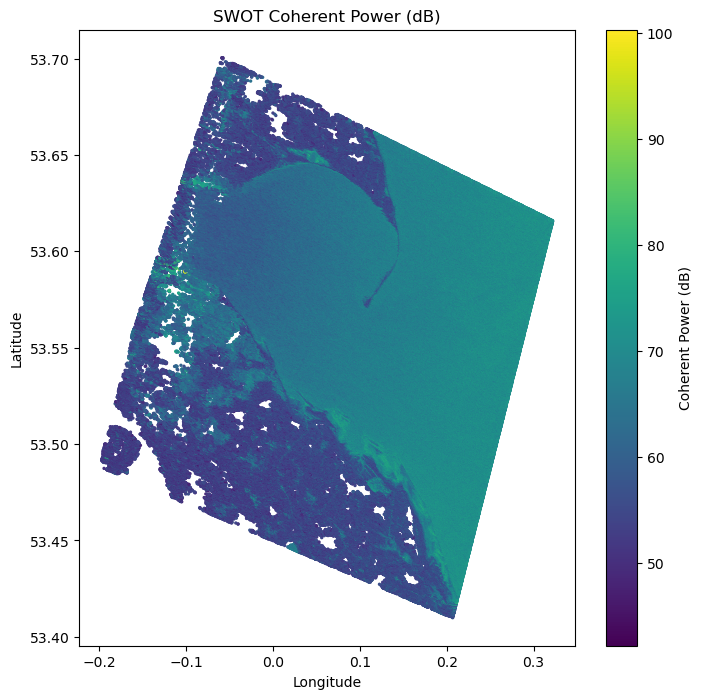

In [42]:
import geopandas as gpd
from shapely.geometry import Polygon, Point

kml = gpd.read_file(
    r"C:\Users\pmalesza\Documents\SWOT kml\subset_grimsby.kml"
)

geom = kml.geometry.iloc[0]

if geom.geom_type == "LineString":
    poly = Polygon(geom.coords)
else:
    poly = geom

mask = np.array([
    poly.covers(Point(lon, lat))
    for lon, lat in zip(
        data.longitude.values,
        data.latitude.values
    )
])


cp = data.coherent_power.values[mask]

cp_db = np.where(cp > 0, 10*np.log10(cp), np.nan)

plt.figure(figsize=(8,8))

plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=cp_db,
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Coherent Power (dB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Coherent Power (dB)")

plt.show()

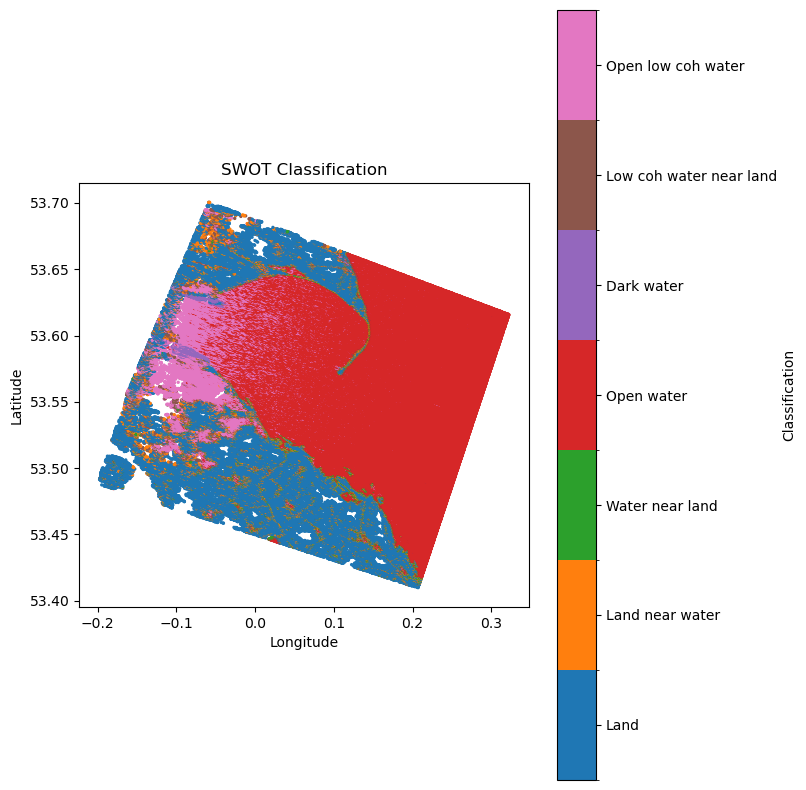

In [43]:
plt.figure(figsize=(8,8))

norm = mcolors.BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5],
    7
)

plt.scatter(
    data.longitude.values[mask],
    data.latitude.values[mask],
    c=data.classification.values[mask],
    s=2,
    cmap="tab10",
    norm=norm
)

cbar = plt.colorbar(label="Classification")
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7])
cbar.set_ticklabels([
    "Land",
    "Land near water",
    "Water near land",
    "Open water",
    "Dark water",
    "Low coh water near land",
    "Open low coh water"
])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Classification")

# Correct aspect ratio for latitude distortion instead of plt.axis("equal")
mean_lat = np.deg2rad(np.mean(data.latitude.values[mask]))
plt.gca().set_aspect(1 / np.cos(mean_lat))

plt.tight_layout()
plt.show()

C:\Users\pmalesza\AppData\Local\Temp\ipykernel_14084\1269275671.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


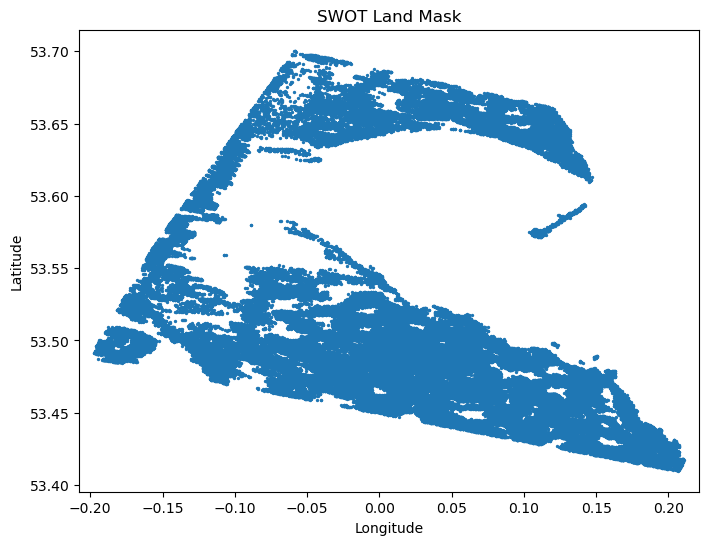

In [13]:
land = mask & (data.classification.values == 1)

plt.figure(figsize=(8, 6))

plt.scatter(
    data.longitude.values[land],
    data.latitude.values[land],
    s=2,
    cmap="tab10"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Land Mask")
plt.axis("equal")
plt.show()

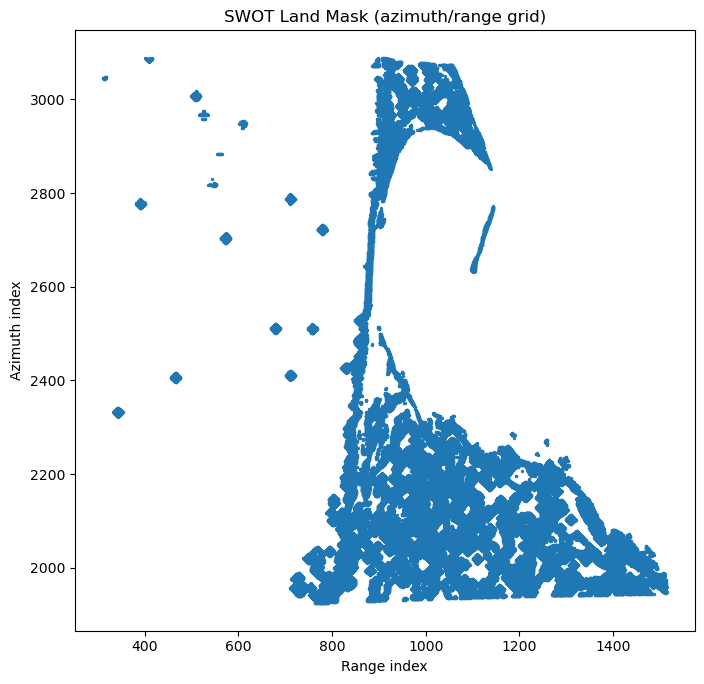

In [14]:
az = data.azimuth_index.values.astype(int)
rg = data.range_index.values.astype(int)

land = mask & (data.classification.values == 1)

az_sub = az[land]
rg_sub = rg[land]

if land.sum() > 0:
    
    az_min, az_max = az_sub.min(), az_sub.max()
    rg_min, rg_max = rg_sub.min(), rg_sub.max()

    #land_grid = np.full((az_max - az_min + 1, rg_max - rg_min + 1), np.nan)
    #land_grid[az_sub - az_min, rg_sub - rg_min] = 1

    land_grid = np.ones((az_max - az_min + 1, rg_max - rg_min + 1), dtype=int)
    land_grid[az_sub - az_min, rg_sub - rg_min] = 0


    plt.figure(figsize=(8, 8))
    plt.scatter(rg_sub, az_sub, s=2, c="tab:blue")
    plt.xlabel("Range index")
    plt.ylabel("Azimuth index")
    plt.title("SWOT Land Mask (azimuth/range grid)")
    plt.gca().set_aspect("equal")
    plt.show()

else:
    print("No land pixels (classification == 1) found in this subset — nothing to plot.")

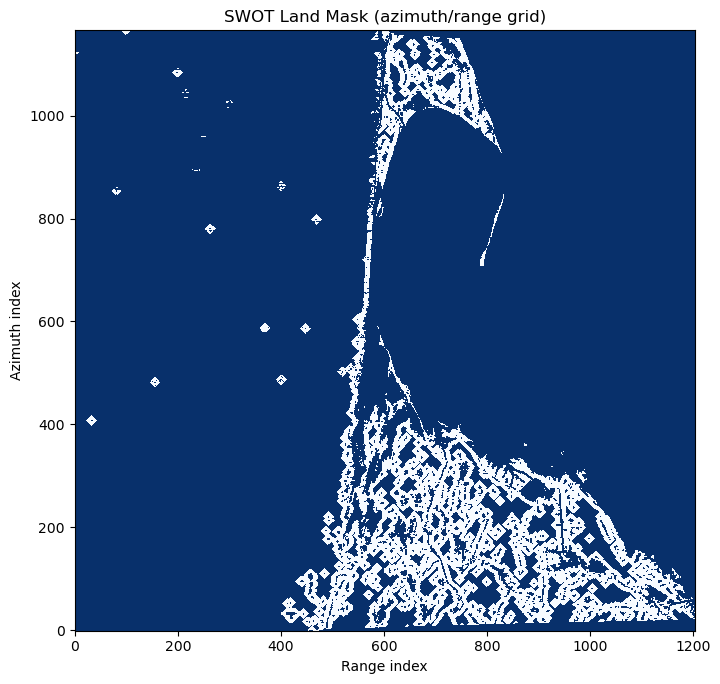

In [15]:
plt.figure(figsize=(8, 8))
plt.imshow(land_grid, cmap="Blues", origin="lower", interpolation="nearest", vmin=0, vmax=1)
plt.xlabel("Range index")
plt.ylabel("Azimuth index")
plt.title("SWOT Land Mask (azimuth/range grid)")
plt.show()

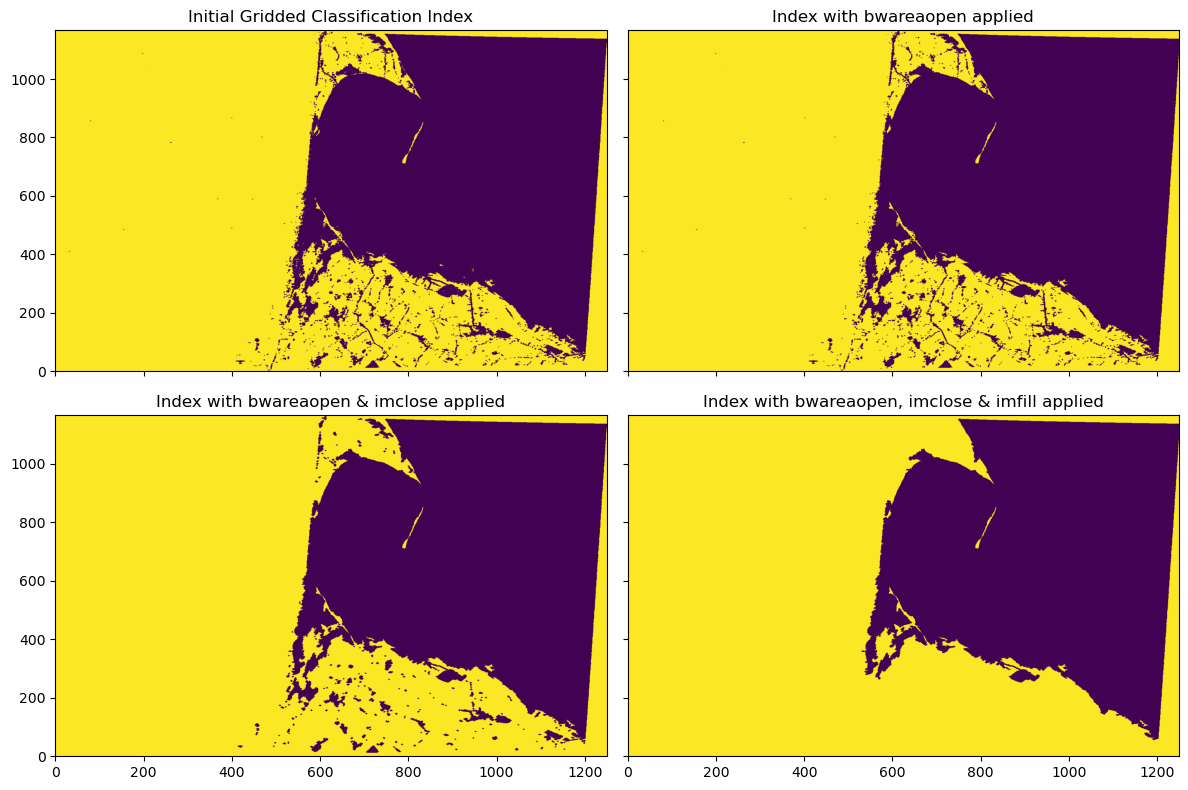

In [16]:
from skimage.morphology import remove_small_objects, binary_closing, disk
from scipy.ndimage import binary_fill_holes

az_sub = az[mask]
rg_sub = rg[mask]
class_sub = data.classification.values[mask]

az_min, az_max = az_sub.min(), az_sub.max()
rg_min, rg_max = rg_sub.min(), rg_sub.max()

n_az = az_max - az_min + 1
n_rg = rg_max - rg_min + 1


class_grid = np.zeros((n_az, n_rg), dtype=bool)
class_grid[az_sub - az_min, rg_sub - rg_min] = (class_sub == 1)


populated = np.zeros((n_az, n_rg), dtype=bool)
populated[az_sub - az_min, rg_sub - rg_min] = True


BW = class_grid | ~populated
se = disk(2)  

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(12, 8))  

axes[0, 0].imshow(BW, origin='lower', aspect='auto')
axes[0, 0].set_title('Initial Gridded Classification Index')

BW1 = remove_small_objects(BW, min_size=50, connectivity=2)   
axes[0, 1].imshow(BW1, origin='lower', aspect='auto')
axes[0, 1].set_title('Index with bwareaopen applied')

BW2 = binary_closing(BW1, se)                                 
axes[1, 0].imshow(BW2, origin='lower', aspect='auto')
axes[1, 0].set_title('Index with bwareaopen & imclose applied')

BW3 = binary_fill_holes(BW2)                                  
axes[1, 1].imshow(BW3, origin='lower', aspect='auto')
axes[1, 1].set_title('Index with bwareaopen, imclose & imfill applied')

plt.tight_layout()
plt.show()

In [ ]:

water_grid = ~BW3


water_mask = water_grid[az_sub - az_min, rg_sub - rg_min]

file = r"\Users\pmalesza\Documents\Python Codes\SWOT_L2_HR_PIXC_052_447_249R_20260705T065937_20260705T065948_PID0_01.nc"

with Dataset(file, "r") as nc:

    pixc = nc.groups["pixel_cloud"]
    tvp = nc.groups["tvp"]

    
    lat = pixc.variables["latitude"][:][mask]
    lon = pixc.variables["longitude"][:][mask]
    height = pixc.variables["height"][:][mask]
    classification = pixc.variables["classification"][:][mask]


valid = (
    water_mask
    & np.isfinite(lat)
    & np.isfinite(lon)
    & np.isfinite(height)
    & (np.abs(height) < 1e4)
)


water_height = height[valid]
water_lat = lat[valid]
water_lon = lon[valid]


Height median: 47.22225
Height standard deviation: 1.2771634


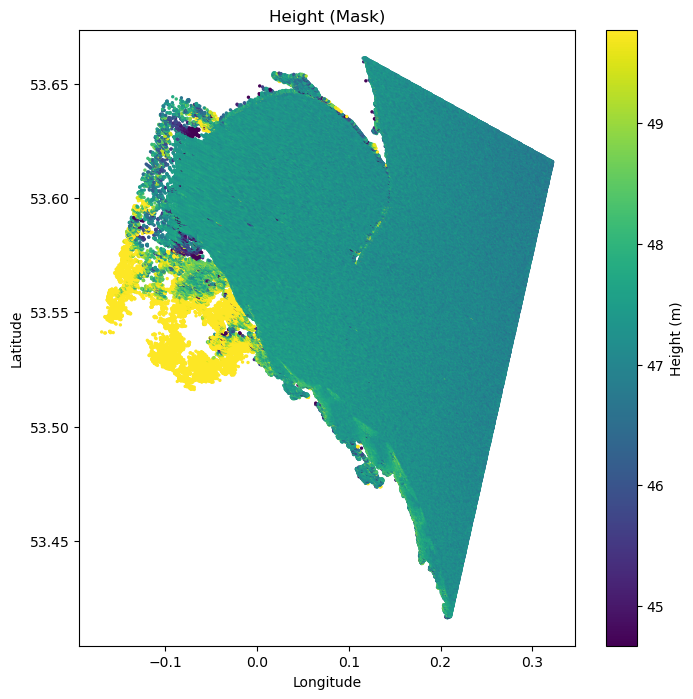

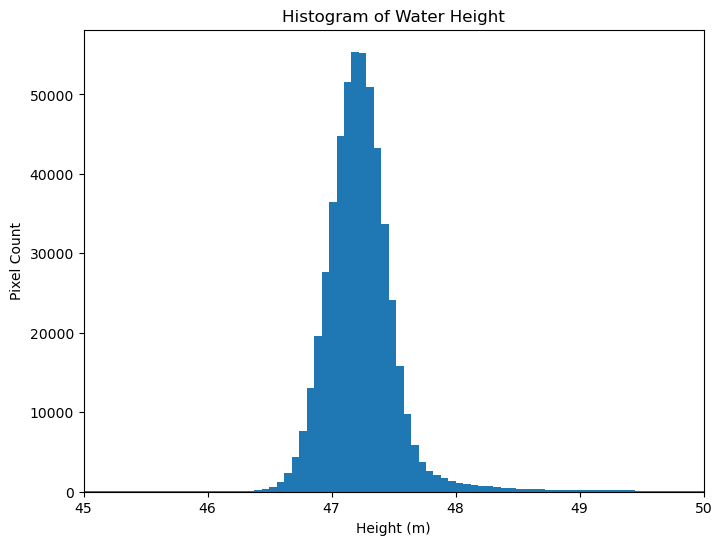

In [41]:
height_median = np.median(water_height)
height_std = np.std(water_height)

vmin = height_median - 2 * height_std
vmax = height_median + 2 * height_std

print('Height median:', height_median)
print('Height standard deviation:', height_std)

plt.figure(figsize=(8, 8))

sc = plt.scatter(
    water_lon,
    water_lat,
    c=water_height,
    s=2,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label='Height (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Height (Mask)')
plt.show()



plt.figure(figsize=(8, 6))
plt.hist(water_height, bins=500)
plt.xlabel('Height (m)')
plt.xlim(45, 50)
plt.ylabel('Pixel Count')
plt.title('Histogram of Water Height')
plt.show()

Median: 69.33 dB
Standard deviation: 3.99 dB
Colour limits: 61.36 to 77.31 dB


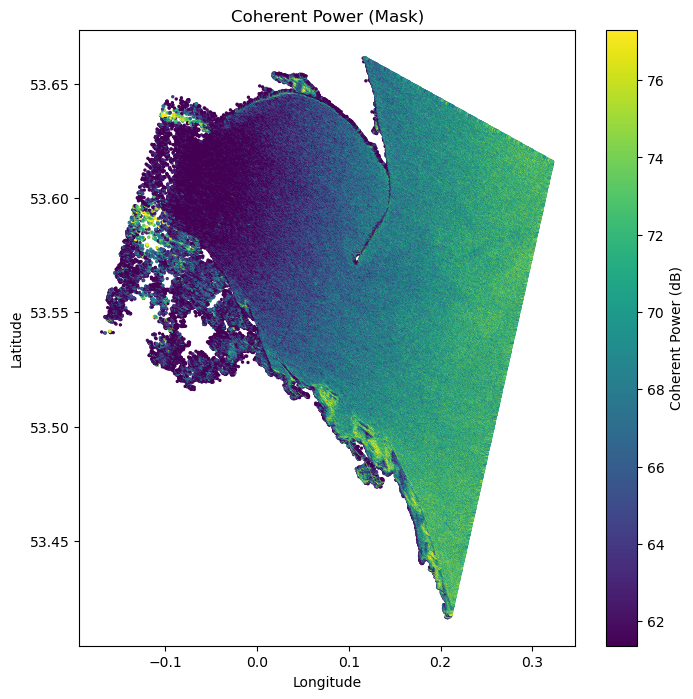

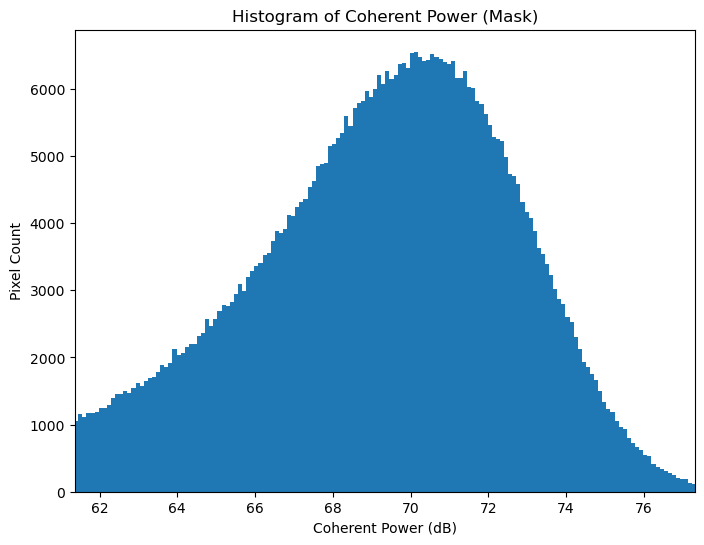

In [ ]:

water_grid = ~BW3

water_mask = water_grid[az_sub - az_min, rg_sub - rg_min]


coherent_power = data.coherent_power.values[mask]
longitude = data.longitude.values[mask]
latitude = data.latitude.values[mask]


valid = (
    water_mask &
    np.isfinite(coherent_power) &
    (coherent_power > 0)
)


cp = coherent_power[valid]
cp_db = 10 * np.log10(cp)

cp_lon = longitude[valid]
cp_lat = latitude[valid]


cp_median = np.median(cp_db)
cp_std = np.std(cp_db)

vmin = cp_median - 2 * cp_std
vmax = cp_median + 2 * cp_std

print(f"Median: {cp_median:.2f} dB")
print(f"Standard deviation: {cp_std:.2f} dB")
print(f"Colour limits: {vmin:.2f} to {vmax:.2f} dB")


plt.figure(figsize=(8, 8))

sc = plt.scatter(
    cp_lon,
    cp_lat,
    c=cp_db,
    s=2,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label="Coherent Power (dB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Coherent Power (Mask)")
plt.show()


plt.figure(figsize=(8, 6))

plt.hist(cp_db, bins=500)

plt.xlabel("Coherent Power (dB)")
plt.ylabel("Pixel Count")
plt.title("Histogram of Coherent Power (Mask)")
plt.xlim(vmin, vmax)

plt.show()

Median: 11.48 dB
Standard deviation: 2.74 dB
Colour limits: 6.00 to 16.96 dB


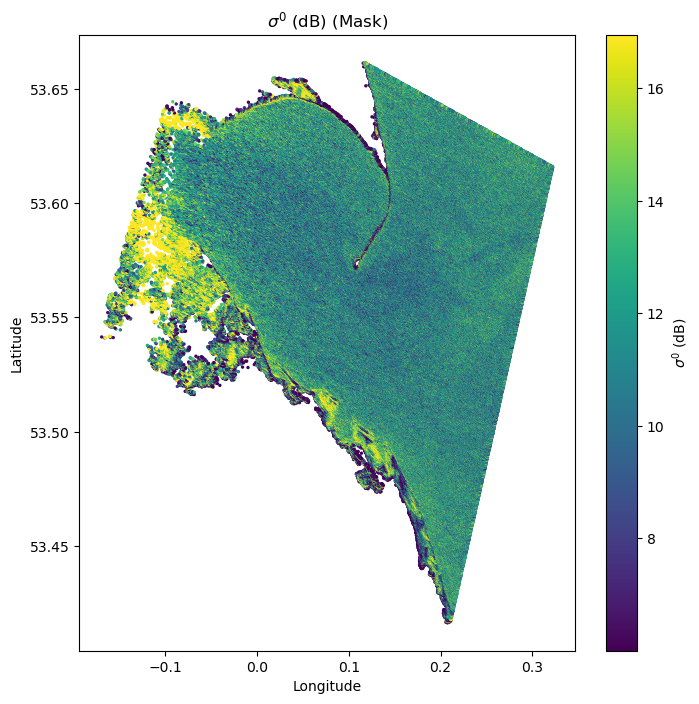

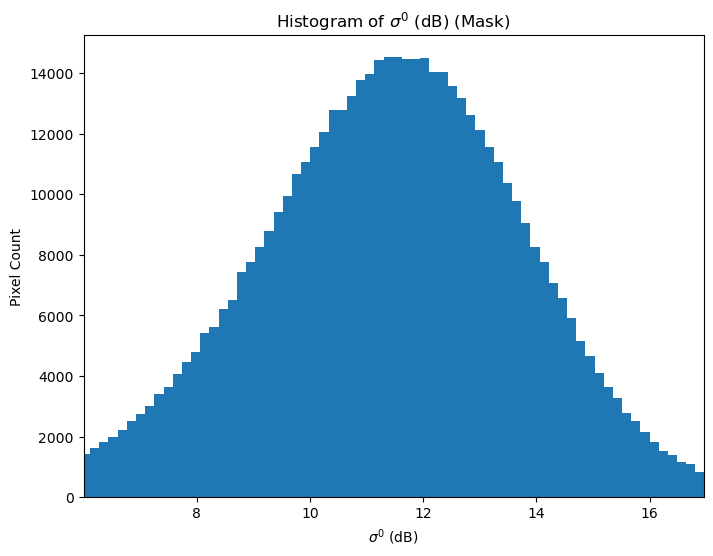

In [ ]:
water_grid = ~BW3

water_mask = water_grid[az_sub - az_min, rg_sub - rg_min]


sig0 = data.sig0.values[mask]
longitude = data.longitude.values[mask]
latitude = data.latitude.values[mask]


valid = (
    water_mask &
    np.isfinite(sig0) &
    (sig0 > 0)
)

sig0 = sig0[valid]
sig0_db = 10 * np.log10(sig0)

sig0_lon = longitude[valid]
sig0_lat = latitude[valid]


sig0_median = np.median(sig0_db)
sig0_std = np.std(sig0_db)

vmin = sig0_median - 2 * sig0_std
vmax = sig0_median + 2 * sig0_std

print(f"Median: {sig0_median:.2f} dB")
print(f"Standard deviation: {sig0_std:.2f} dB")
print(f"Colour limits: {vmin:.2f} to {vmax:.2f} dB")


plt.figure(figsize=(8, 8))

sc = plt.scatter(
    sig0_lon,
    sig0_lat,
    c=sig0_db,
    s=2,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label=r"$\sigma^0$ (dB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(r"$\sigma^0$ (dB) (Mask)")
plt.show()


plt.figure(figsize=(8, 6))

plt.hist(sig0_db, bins=500)

plt.xlabel(r"$\sigma^0$ (dB)")
plt.ylabel("Pixel Count")
plt.title(r"Histogram of $\sigma^0$ (dB) (Mask)")
plt.xlim(vmin, vmax)

plt.show()

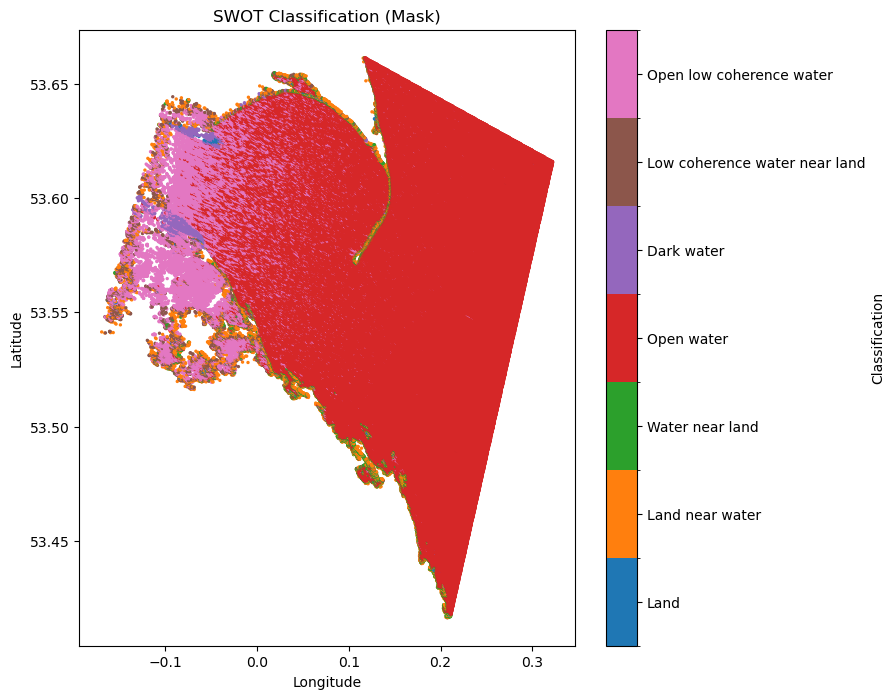

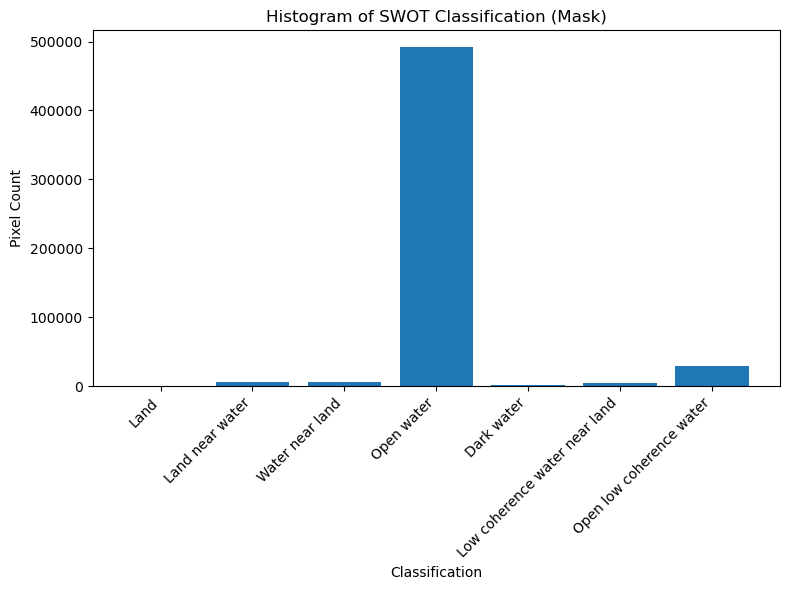

In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt


water_grid = ~BW3


water_mask = water_grid[az_sub - az_min, rg_sub - rg_min]


classification = data.classification.values[mask]
longitude = data.longitude.values[mask]
latitude = data.latitude.values[mask]


valid = (
    water_mask &
    np.isfinite(classification)
)

classification = classification[valid]
class_lon = longitude[valid]
class_lat = latitude[valid]

class_labels = [
    "Land",
    "Land near water",
    "Water near land",
    "Open water",
    "Dark water",
    "Low coherence water near land",
    "Open low coherence water"
]

norm = mcolors.BoundaryNorm(
    np.arange(0.5, 8.5, 1),
    7
)

plt.figure(figsize=(8, 8))

sc = plt.scatter(
    class_lon,
    class_lat,
    c=classification,
    s=2,
    cmap="tab10",
    norm=norm
)

cbar = plt.colorbar(sc, ticks=np.arange(1, 8))
cbar.set_label("Classification")
cbar.set_ticklabels(class_labels)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Classification (Mask)")

plt.show()

plt.figure(figsize=(8, 6))

plt.hist(
    classification,
    bins=np.arange(0.5, 8.5, 1),
    rwidth=0.8
)

plt.xticks(
    np.arange(1, 8),
    class_labels,
    rotation=45,
    ha="right"
)

plt.xlabel("Classification")
plt.ylabel("Pixel Count")
plt.title("Histogram of SWOT Classification (Mask)")

plt.tight_layout()
plt.show()

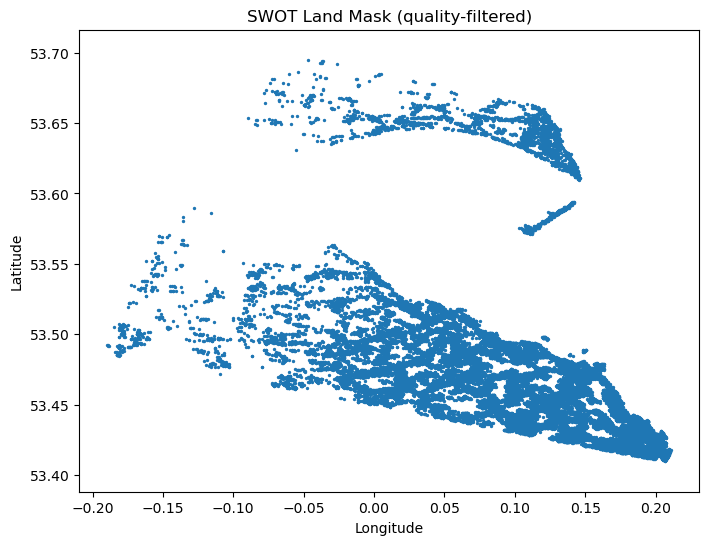

In [44]:
land = (
    mask
    & (data.classification.values == 1)
    & (data.classification_qual.values == 0)
    #& (data.geolocation_qual.values == 0)
    & (data.interferogram_qual.values == 0)
    & (data.sig0_qual.values == 0)
)

plt.figure(figsize=(8, 6))

plt.scatter(
    data.longitude.values[land],
    data.latitude.values[land],
    s=2,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT Land Mask (quality-filtered)")
plt.axis("equal")
plt.show()

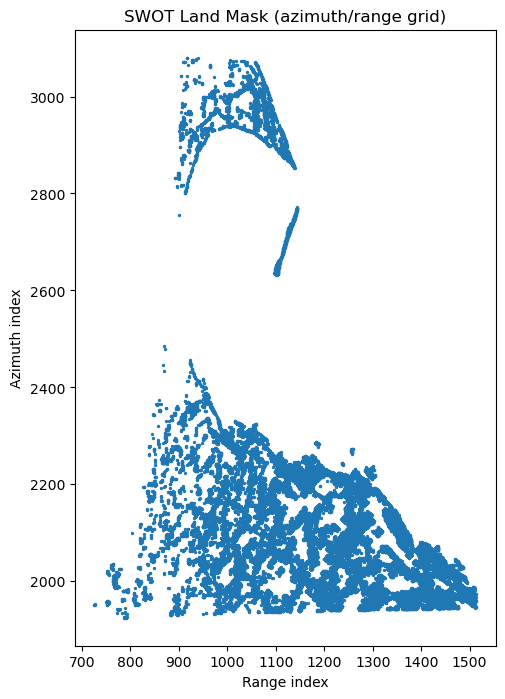

In [45]:
az = data.azimuth_index.values.astype(int)
rg = data.range_index.values.astype(int)

land = (
    mask
    & (data.classification.values == 1)
    & (data.classification_qual.values == 0)
    #& (data.geolocation_qual.values == 0)
    & (data.interferogram_qual.values == 0)
    & (data.sig0_qual.values == 0)
)

az_sub = az[land]
rg_sub = rg[land]

if land.sum() > 0:
    
    az_min, az_max = az_sub.min(), az_sub.max()
    rg_min, rg_max = rg_sub.min(), rg_sub.max()

    #land_grid = np.full((az_max - az_min + 1, rg_max - rg_min + 1), np.nan)
    #land_grid[az_sub - az_min, rg_sub - rg_min] = 1

    land_grid = np.ones((az_max - az_min + 1, rg_max - rg_min + 1), dtype=int)
    land_grid[az_sub - az_min, rg_sub - rg_min] = 0


    plt.figure(figsize=(8, 8))
    plt.scatter(rg_sub, az_sub, s=2, c="tab:blue")
    plt.xlabel("Range index")
    plt.ylabel("Azimuth index")
    plt.title("SWOT Land Mask (azimuth/range grid)")
    plt.gca().set_aspect("equal")
    plt.show()

else:
    print("No land pixels (classification == 1) found in this subset — nothing to plot.")

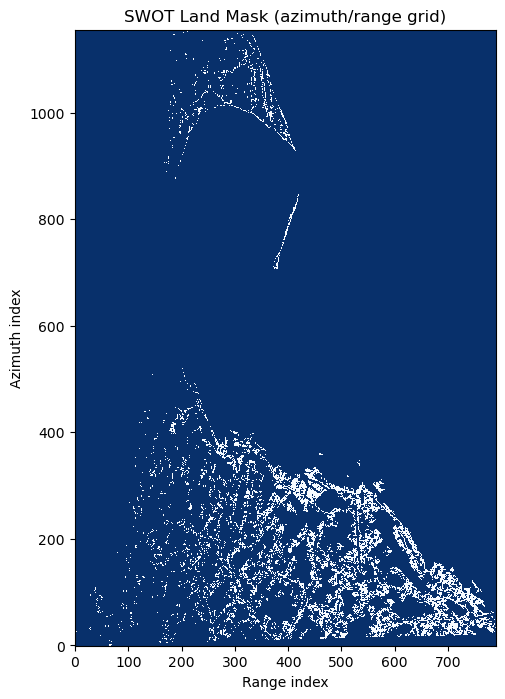

In [46]:
plt.figure(figsize=(8, 8))
plt.imshow(land_grid, cmap="Blues", origin="lower", interpolation="nearest", vmin=0, vmax=1)
plt.xlabel("Range index")
plt.ylabel("Azimuth index")
plt.title("SWOT Land Mask (azimuth/range grid)")
plt.show()

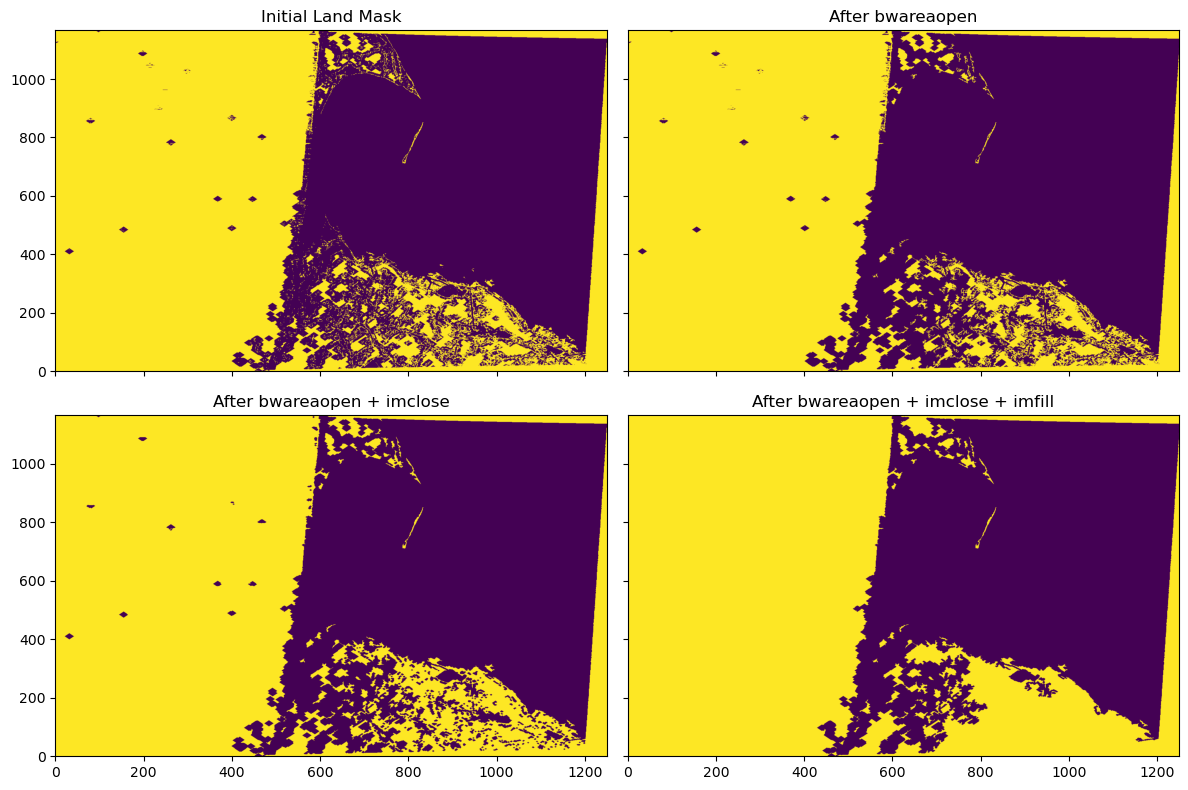

In [47]:
from skimage.morphology import remove_small_objects, binary_closing, disk
from scipy.ndimage import binary_fill_holes
import matplotlib.pyplot as plt

az = data.azimuth_index.values.astype(int)
rg = data.range_index.values.astype(int)

land_class = (
    mask
    & (data.classification.values == 1)
    & (data.classification_qual.values == 0)
    & (data.interferogram_qual.values == 0)
    & (data.sig0_qual.values == 0)
)

az_sub = az[mask]
rg_sub = rg[mask]
land_sub = land_class[mask]

az_min, az_max = az_sub.min(), az_sub.max()
rg_min, rg_max = rg_sub.min(), rg_sub.max()
n_az = az_max - az_min + 1
n_rg = rg_max - rg_min + 1

#land_grid = np.ones((az_max - az_min + 1, rg_max - rg_min + 1), dtype=int)
#land_grid[az_sub - az_min, rg_sub - rg_min] = 0

land_grid = np.zeros((n_az, n_rg), dtype=bool)
land_grid[az_sub - az_min, rg_sub - rg_min] = land_sub

populated = np.zeros((n_az, n_rg), dtype=bool)
populated[az_sub - az_min, rg_sub - rg_min] = True

#populated = np.zeros((n_az, n_rg), dtype=int)
#populated[az_sub - az_min, rg_sub - rg_min] = True

BW = land_grid | ~populated   
se = disk(2)

BW1 = remove_small_objects(BW, min_size=50, connectivity=2)
BW2 = binary_closing(BW1, se)
BW3 = binary_fill_holes(BW2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
titles = [
    "Initial Land Mask",
    "After bwareaopen",
    "After bwareaopen + imclose",
    "After bwareaopen + imclose + imfill",
]
for ax, img, title in zip(axes.ravel(), [BW, BW1, BW2, BW3], titles):
    ax.imshow(img, origin="lower", aspect="auto")
    ax.set_title(title)
plt.tight_layout()
plt.show()

land_mask_clean = BW3

In [48]:
from netCDF4 import Dataset

water_grid = ~BW3
water_mask = water_grid[az_sub - az_min, rg_sub - rg_min]

file = r"\Users\pmalesza\Documents\Python Codes\SWOT_L2_HR_PIXC_052_447_249R_20260705T065937_20260705T065948_PID0_01.nc"

with Dataset(file, "r") as nc:

    pixc = nc.groups["pixel_cloud"]
    tvp = nc.groups["tvp"]

    lat = pixc.variables["latitude"][:][mask]
    lon = pixc.variables["longitude"][:][mask]
    height = pixc.variables["height"][:][mask]
    classification = pixc.variables["classification"][:][mask]
    geolocation_qual = pixc.variables["geolocation_qual"][:][mask]   # NEW

valid = (
    water_mask
    & np.isfinite(lat)
    & np.isfinite(lon)
    & np.isfinite(height)
    & (np.abs(height) < 1e4)
    & (geolocation_qual == 0)   
)

water_height = height[valid]
water_lat = lat[valid]
water_lon = lon[valid]

c:\Users\pmalesza\anaconda3\envs\depth-calculation\Lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Height median: 47.209938
Height standard deviation: 0.2476916


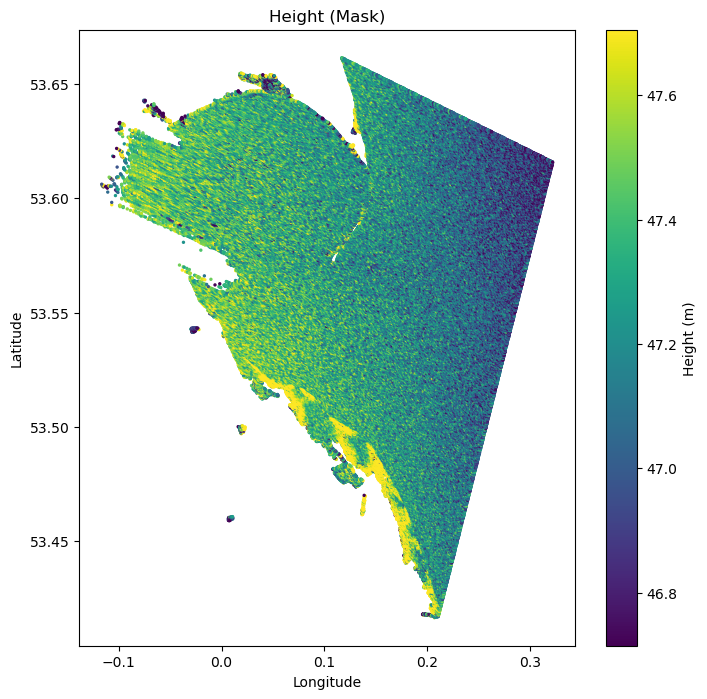

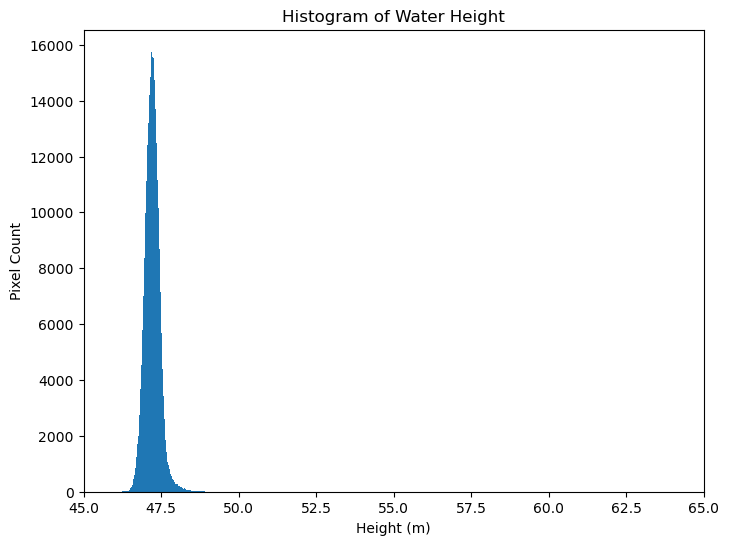

In [49]:
height_median = np.median(water_height)
height_std = np.std(water_height)

vmin = height_median - 2 * height_std
vmax = height_median + 2 * height_std

print('Height median:', height_median)
print('Height standard deviation:', height_std)

plt.figure(figsize=(8, 8))

sc = plt.scatter(
    water_lon,
    water_lat,
    c=water_height,
    s=2,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label='Height (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Height (Mask)')
plt.show()



plt.figure(figsize=(8, 6))
plt.hist(water_height, bins=500)
plt.xlabel('Height (m)')
plt.xlim(45, 65)
plt.ylabel('Pixel Count')
plt.title('Histogram of Water Height')
plt.show()